In [8]:
import altitude_helper
from altitude_helper import *
import skymap_data_helper

import importlib
importlib.reload(altitude_helper)


<module 'altitude_helper' from '/home/molidae/Desktop/berkeley/ssl/altitude_helper.py'>

In [2]:
#load an hour of data
site_yknf = 'yknf'
site_fsmi = 'fsmi'
date = datetime(2024,8,30)
hour = 5 #this is in UT

rgb_asi_skymap_lookup_df = skymap_data_helper.build_rgb_asi_skymap_lookup_table(directory='./trex-rgb-asi_data') #CHANGE TO YOUR SKYMAP DIRECTORY!
yknf_rgb_asi_ds = skymap_data_helper.load_rgb_asi_hour_to_xarray(site_yknf, date, hour, rgb_asi_skymap_lookup_df,data_dir='./trex-rgb-asi_data', skymap_dir='./trex-rgb-asi_data') #CHANGE DIRECTORIES!
fsmi_rgb_asi_ds = skymap_data_helper.load_rgb_asi_hour_to_xarray(site_fsmi, date, hour, rgb_asi_skymap_lookup_df,data_dir='./trex-rgb-asi_data', skymap_dir='./trex-rgb-asi_data') #CHANGE DIRECTORIES!


Skymap file:
rgb_skymap_yknf_20240829-%2B_v01.sav
skymap path:
./trex-rgb-asi_data/rgb_skymap_yknf_20240829-%2B_v01.sav
Skymap file:
rgb_skymap_fsmi_20240808-%2B_v01.sav
skymap path:
./trex-rgb-asi_data/rgb_skymap_fsmi_20240808-%2B_v01.sav


In [142]:
h_target = 150000 

lat_yknf = yknf_rgb_asi_ds.attrs["site_latitude"]
lon_yknf = yknf_rgb_asi_ds.attrs["site_longitude"]
full_elevation_yknf = yknf_rgb_asi_ds["elevation"]
full_azimuth_yknf = yknf_rgb_asi_ds["azimuth"]

full_yknf_lat110 = np.array(yknf_rgb_asi_ds.lat_110)
full_yknf_lon110 = np.array(yknf_rgb_asi_ds.lon_110)
yknf_110_mask = np.isnan(full_yknf_lat110) | np.isnan(full_yknf_lon110) # apply this mask to all frames across all elevations for YKNF


print(full_yknf_lat110.shape)

lat_fsmi = fsmi_rgb_asi_ds.attrs["site_latitude"]
lon_fsmi = fsmi_rgb_asi_ds.attrs["site_longitude"]
full_elevation_fsmi = fsmi_rgb_asi_ds["elevation"]
full_azimuth_fsmi = fsmi_rgb_asi_ds["azimuth"]

full_fsmi_lat110 = np.array(fsmi_rgb_asi_ds.lat_110)
full_fsmi_lon110 = np.array(fsmi_rgb_asi_ds.lon_110)
fsmi_110_mask = np.isnan(full_fsmi_lat110) | np.isnan(full_fsmi_lon110) # apply this mask to all frames across all elevations for YKNF


yknf_lat_110_proj, yknf_lon_110_proj = project_lat_lon(full_azimuth_yknf, 
                                                     full_elevation_yknf, 
                                                     lat_yknf, 
                                                     lon_yknf, 
                                                     h_target, 
                                                     yknf_110_mask)

fsmi_lat_110_proj, fsmi_lon_110_proj = project_lat_lon(full_azimuth_fsmi, 
                                                     full_elevation_fsmi, 
                                                     lat_fsmi, 
                                                     lon_fsmi, 
                                                     h_target, 
                                                     fsmi_110_mask)


(480, 553)


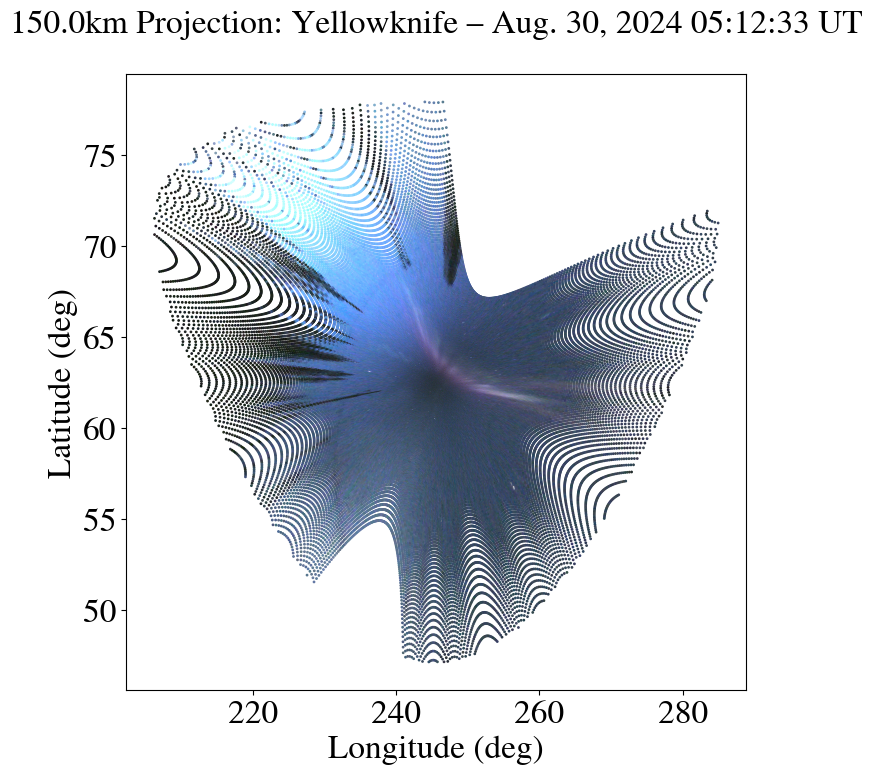

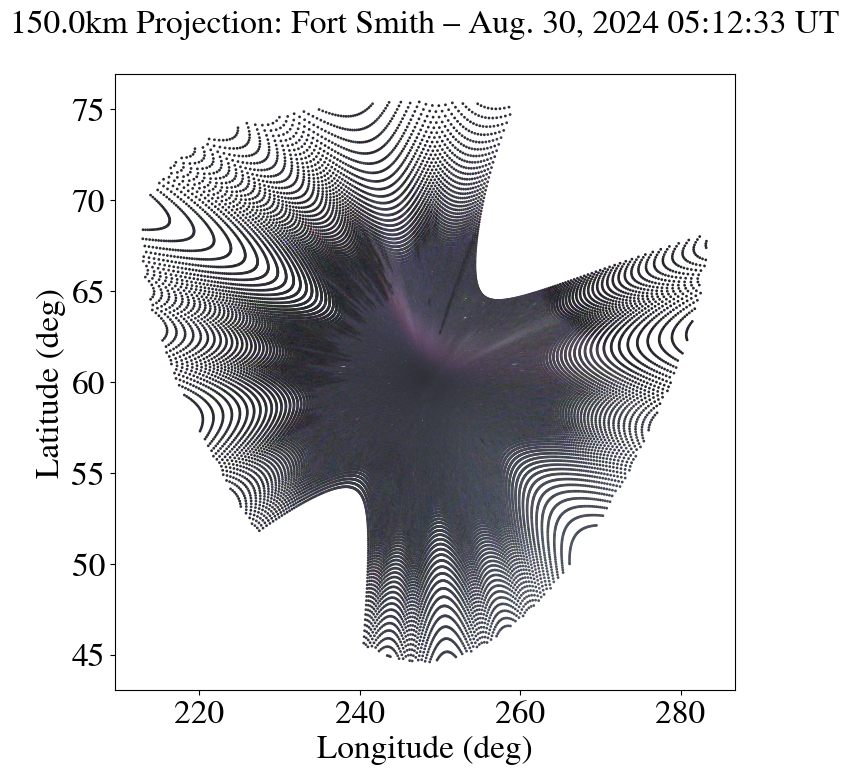

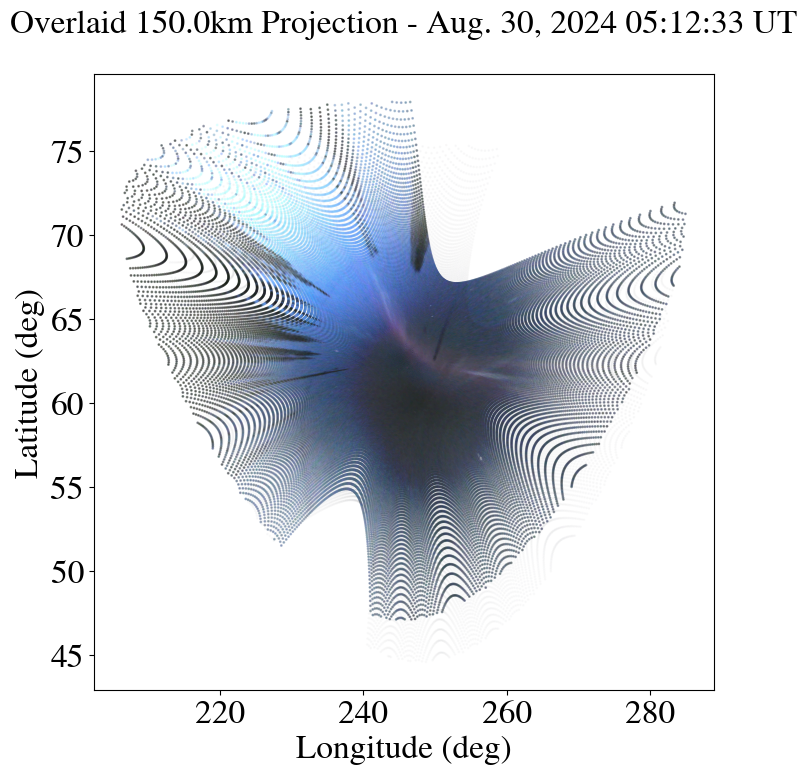

In [143]:
time_index = 251 # 5:10 UTC
site_name_yknf = "Yellowknife" 
site_name_fsmi = "Fort Smith" 

yknf_rgb, fsmi_rgb = plot_lat_lon(yknf_rgb_asi_ds, 
                                 fsmi_rgb_asi_ds, 
                                 time_index, 
                                 site_name_yknf, 
                                 site_name_fsmi, 
                                 yknf_lat_110_proj, 
                                 yknf_lon_110_proj, 
                                 fsmi_lat_110_proj, 
                                 fsmi_lon_110_proj,
                                 h_target)

### Linear Interpolation
1. define a common grid over which to perform the interpolation --> this common grid is based on the maximum and minimum latitude/longitude BEFORE masking
- get the overlapping area
3. interpolate the pixel intensities from both cameras over this entire grid
4. mask out the aurora overlap pixels --> do a quick and dirty version first, then clean it up (make it flexible enough to be run on all time)
5. calculate the similarity between the interpolated pixels, and do some overall metric to see how things are lining up
- try MSE

In [144]:
from scipy.ndimage import gaussian_filter
from skimage.filters import threshold_local
from skimage.morphology import skeletonize, remove_small_objects
from skimage.filters import frangi

def masking(intensity):
    ''' 
    Isolates the auroral structure; accounting for large white patches in the background.
    Applies background filter (removing large-scale variations), local thresholding (patching), smoothing (removing stars)

    Parameters:
        intensity = 2D array of pixel intensities in grayscale (typically after interpolation)

    Returns:
        final_mask = final masked used, helpful for visualization
        masked_intensity = 2D array of pixel intensities after masking 
        
    '''

    # background subtraction
    sigma_bg = 20 # std dev for gaussian kernel 
    background = gaussian_filter(intensity, sigma=sigma_bg)
    img_background_removed = intensity - background 

    # smoothing
    smoothed = gaussian_filter(img_background_removed, sigma=0.5)  # sigma=1 --> small smoothing, merge aurora pixels

    # frangi filter --> helps for thin, elongated structures (erased too much)
    # frangi_filter = frangi(smoothed)
    
    # local thresholding --> replaced by frangi
    blocksize = 61 # local patch size
    offset = 0
    threshold_mask = img_background_removed > threshold_local(img_background_removed, blocksize, offset=offset)
    #img_thresholded = np.where(threshold_mask, img_background_removed, np.nan)

    # preserving elongated thin objects --> erased too much
    # skeleton = skeletonize(threshold_mask)
    # clean_mask = remove_small_objects(skeleton, min_size=5)

    

    # mask = frangi_filter > 0.1
    # final_mask = remove_small_objects(mask, min_size=5)
    final_mask = threshold_mask
    masked_intensity = np.where(final_mask, intensity, np.nan)
    
    return final_mask, masked_intensity  
    

In [174]:
from scipy.interpolate import griddata
from scipy.stats import pearsonr
from PIL import Image

# grid boundaries --> intersection of the fields of view for YKNF and FSMI
lat_min = max(np.nanmin(yknf_lat_110_proj), np.nanmin(fsmi_lat_110_proj))
lon_min = max(np.nanmin(yknf_lon_110_proj), np.nanmin(fsmi_lon_110_proj))
lat_max = min(np.nanmax(yknf_lat_110_proj), np.nanmax(fsmi_lat_110_proj))
lon_max = min(np.nanmax(yknf_lon_110_proj), np.nanmax(fsmi_lon_110_proj))



# grid --> need to make this more sophisticated, bc some distortion from using the dims of az/el grid
n_lat = 500
n_lon = 500
lat_grid = np.linspace(lat_min, lat_max, n_lat)
lon_grid = np.linspace(lon_min, lon_max, n_lon)
lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)

# enhance color channels to make purple/green brighter when converted to greyscale
yknf_enhanced = yknf_rgb.copy()
yknf_enhanced[:,:,1] = np.clip(yknf_enhanced[:,:,1]*1.5, 0, 255) # green channel
yknf_enhanced[:,:,0] = np.clip(yknf_enhanced[:,:,0]*1.2, 0, 255) # red channel
yknf_enhanced[:,:,2] = np.clip(yknf_enhanced[:,:,2]*1.2, 0, 255) # blue channel
fsmi_enhanced = fsmi_rgb.copy()
fsmi_enhanced[:,:,1] = np.clip(fsmi_enhanced[:,:,1]*1.5, 0, 255) # green channel
fsmi_enhanced[:,:,0] = np.clip(fsmi_enhanced[:,:,0]*1.2, 0, 255) # red channel
fsmi_enhanced[:,:,2] = np.clip(fsmi_enhanced[:,:,2]*1.2, 0, 255) # blue channel

# convert to greyscale
yknf_img = Image.fromarray(yknf_enhanced)
yknf_grayscale = yknf_img.convert('L')
yknf_grayscale_arr = np.array(yknf_grayscale)
fsmi_img = Image.fromarray(fsmi_enhanced)
fsmi_grayscale = fsmi_img.convert('L')
fsmi_grayscale_arr = np.array(fsmi_grayscale)

# flatten yknf and fsmi projected + grayscale
yknf_flattened_points = np.column_stack((yknf_lon_110_proj.flatten(), yknf_lat_110_proj.flatten())) # (N,2) pairs of (lat, lon)
yknf_grayscale_flattened_values = yknf_grayscale_arr.flatten()
fsmi_flattened_points = np.column_stack((fsmi_lon_110_proj.flatten(), fsmi_lat_110_proj.flatten()))
fsmi_grayscale_flattened_values = fsmi_grayscale_arr.flatten()

# clip YKNF and FSMI to intersection before interpolation
# intersection_mask = (yknf_flattened_points[:,0] >= lon_min) & (yknf_flattened_points[:,0] <= lon_max) & \
#        (yknf_flattened_points[:,1] >= lat_min) & (yknf_flattened_points[:,1] <= lat_max)
# yknf_points_clipped = yknf_flattened_points[intersection_mask]
# yknf_values_clipped = yknf_grayscale_flattened_values[intersection_mask]
# fsmi_points_clipped = fsmi_flattened_points[intersection_mask]
# fsmi_values_clipped = fsmi_grayscale_flattened_values[intersection_mask]

# remove NaNs
yknf_nan_mask = (np.isfinite(yknf_flattened_points).all(axis=1) & np.isfinite(yknf_grayscale_flattened_values))
fsmi_nan_mask = (np.isfinite(fsmi_flattened_points).all(axis=1) & np.isfinite(fsmi_grayscale_flattened_values))

yknf_points_clean = yknf_flattened_points[yknf_nan_mask]
yknf_values_clean = yknf_grayscale_flattened_values[yknf_nan_mask]
fsmi_points_clean = fsmi_flattened_points[fsmi_nan_mask]
fsmi_values_clean = fsmi_grayscale_flattened_values[fsmi_nan_mask]

# interpolation 
yknf_interp_intensity = griddata(yknf_points_clean, yknf_values_clean, (lon_mesh, lat_mesh), method='linear')
fsmi_interp_intensity = griddata(fsmi_points_clean, fsmi_values_clean, (lon_mesh, lat_mesh), method='linear')

# correlation between the interpolated yknf and fsmi values (need to flatten and remove NaNs for pearson)
# yknf_interp_intensity_flat = yknf_interp_intensity.flatten()
# fsmi_interp_intensity_flat = fsmi_interp_intensity.flatten()
# valid = ~np.isnan(yknf_interp_intensity_flat) & ~np.isnan(fsmi_interp_intensity_flat)
# yknf_interp_valid = yknf_interp_intensity_flat[valid]
# fsmi_interp_valid = fsmi_interp_intensity_flat[valid]

# masking out non-auroral background
# yknf_threshold = np.nanpercentile(yknf_interp_intensity, 90)
# fsmi_threshold = np.nanpercentile(fsmi_interp_intensity, 90)
# yknf_aurora_mask = yknf_interp_intensity > yknf_threshold
# fsmi_aurora_mask = fsmi_interp_intensity > fsmi_threshold

# # get only auroras
# yknf_interp_aurora = np.where(yknf_aurora_mask, yknf_interp_intensity, np.nan)
# fsmi_interp_aurora = np.where(fsmi_aurora_mask, fsmi_interp_intensity, np.nan)

# yknf_interp_aurora_flat = yknf_interp_aurora.flatten()
# fsmi_interp_aurora_flat = fsmi_interp_aurora.flatten()

# masking
yknf_aurora = masking(yknf_interp_intensity)
fsmi_aurora = masking(fsmi_interp_intensity)


# remove NaNs
valid = ~np.isnan(yknf_interp_aurora_flat) & ~np.isnan(fsmi_interp_aurora_flat)
yknf_interp_valid = yknf_interp_aurora_flat[valid]
fsmi_interp_valid = fsmi_interp_aurora_flat[valid]

corr, _ = pearsonr(yknf_interp_valid, fsmi_interp_valid)
print("YKNF and FSMI intensity correlation:", corr)


YKNF and FSMI intensity correlation: 0.013315002255889863


In [175]:
yknf_img.show()
fsmi_img.show()


(viewnior:85565): Gtk-CRITICAL **: 15:17:08.174: _gtk_css_image_get_concrete_size: assertion 'default_width > 0' failed

(viewnior:85565): Gtk-CRITICAL **: 15:17:08.174: _gtk_css_image_get_surface: assertion 'surface_width > 0' failed

(viewnior:85565): Gtk-CRITICAL **: 15:17:08.174: _gtk_css_image_get_concrete_size: assertion 'default_width > 0' failed

(viewnior:85565): Gtk-CRITICAL **: 15:17:08.174: _gtk_css_image_get_surface: assertion 'surface_width > 0' failed

(viewnior:85588): Gtk-CRITICAL **: 15:17:08.358: _gtk_css_image_get_concrete_size: assertion 'default_width > 0' failed

(viewnior:85588): Gtk-CRITICAL **: 15:17:08.359: _gtk_css_image_get_surface: assertion 'surface_width > 0' failed

(viewnior:85588): Gtk-CRITICAL **: 15:17:08.359: _gtk_css_image_get_concrete_size: assertion 'default_width > 0' failed

(viewnior:85588): Gtk-CRITICAL **: 15:17:08.359: _gtk_css_image_get_surface: assertion 'surface_width > 0' failed


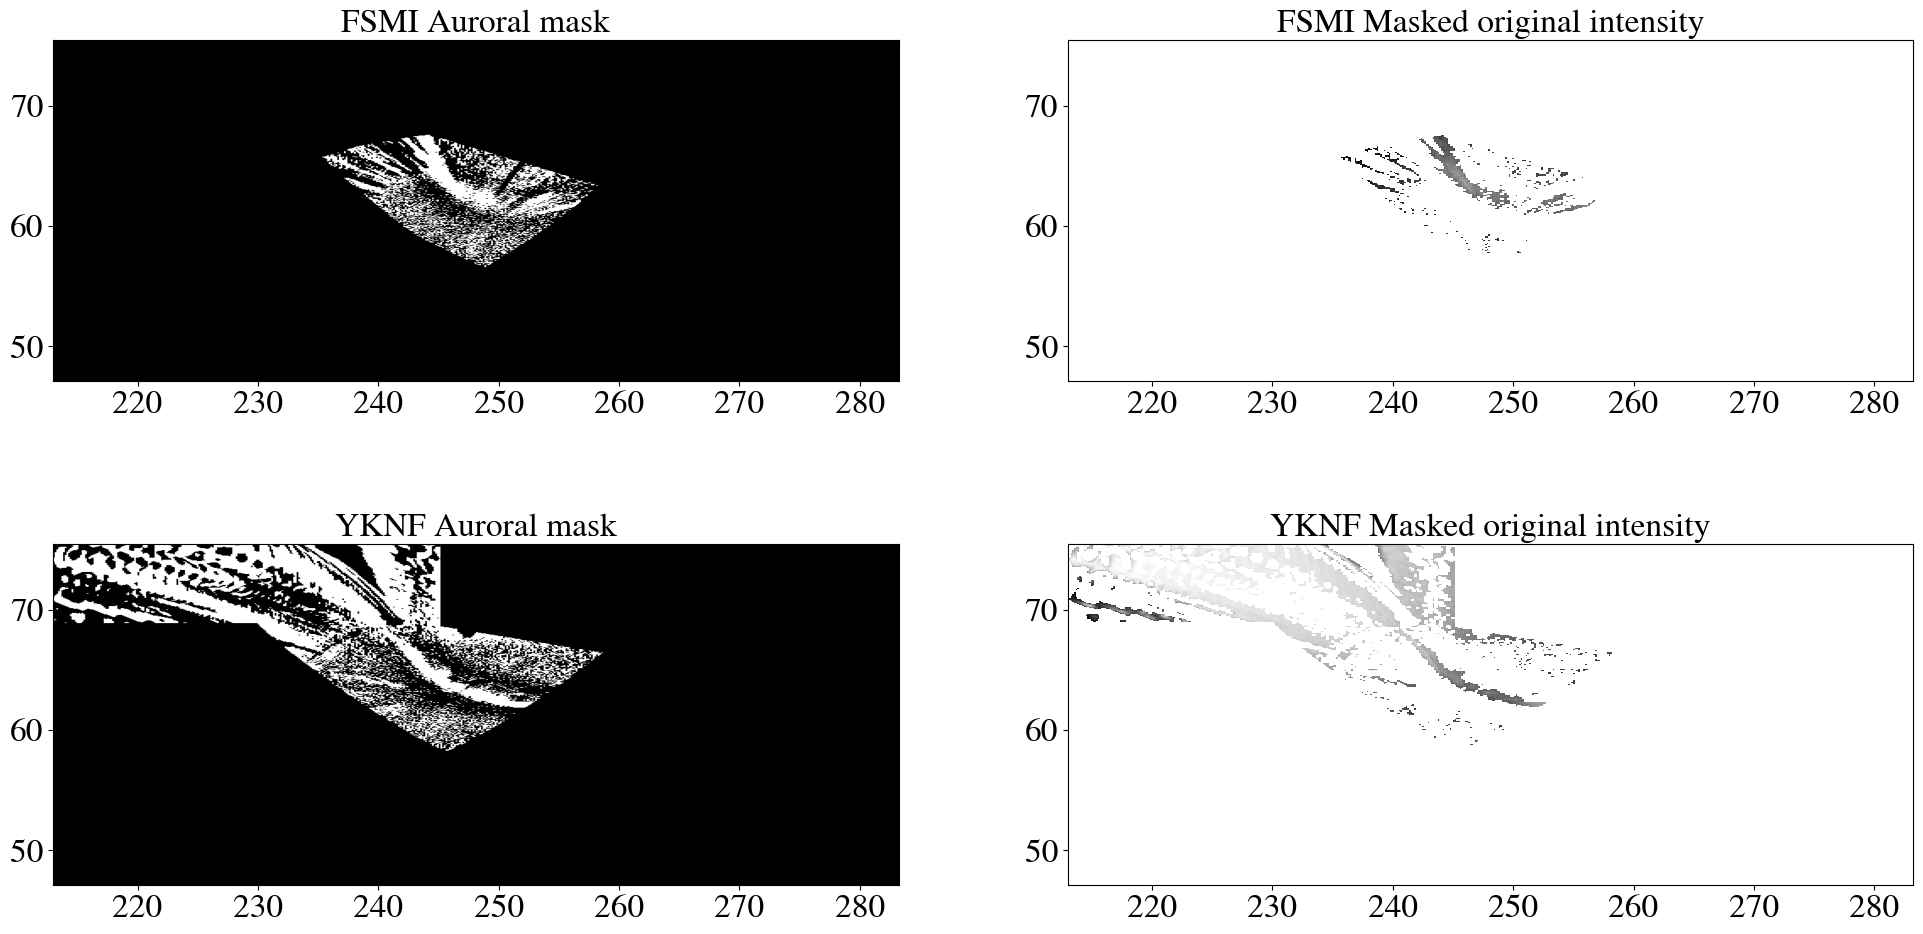

In [176]:
fsmi_final_mask, fsmi_masked_intensity = masking(fsmi_interp_intensity)
yknf_final_mask, yknf_masked_intensity = masking(yknf_interp_intensity)

valid = ~np.isnan(fsmi_masked_intensity) & ~np.isnan(yknf_masked_intensity)
yknf_interp_valid = fsmi_masked_intensity[valid]
fsmi_interp_valid = yknf_masked_intensity[valid]

#corr, _ = pearsonr(yknf_interp_valid, fsmi_interp_valid)
#print("YKNF and FSMI intensity correlation:", corr)


plt.figure(figsize=(24,12))

# Mask
plt.subplot(2,2,1)
plt.imshow(fsmi_final_mask, cmap='gray', origin='lower',
           extent=(lon_min, lon_max, lat_min, lat_max))
plt.title("FSMI Auroral mask")

# Masked intensity
plt.subplot(2,2,2)
plt.imshow(fsmi_masked_intensity, cmap='gray', origin='lower',
           extent=(lon_min, lon_max, lat_min, lat_max))
plt.title("FSMI Masked original intensity")

plt.subplot(2,2,3)
plt.imshow(yknf_final_mask, cmap='gray', origin='lower',
           extent=(lon_min, lon_max, lat_min, lat_max))
plt.title("YKNF Auroral mask")

# Masked intensity
plt.subplot(2,2,4)
plt.imshow(yknf_masked_intensity, cmap='gray', origin='lower',
           extent=(lon_min, lon_max, lat_min, lat_max))
plt.title("YKNF Masked original intensity")


plt.show()


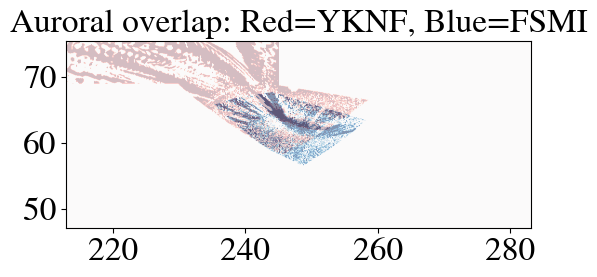

In [177]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.imshow(yknf_final_mask, alpha=0.5, cmap='Reds', origin='lower', extent=(lon_min, lon_max, lat_min, lat_max))
plt.imshow(fsmi_final_mask, alpha=0.5, cmap='Blues', origin='lower', extent=(lon_min, lon_max, lat_min, lat_max))
plt.title("Auroral overlap: Red=YKNF, Blue=FSMI")
plt.show()


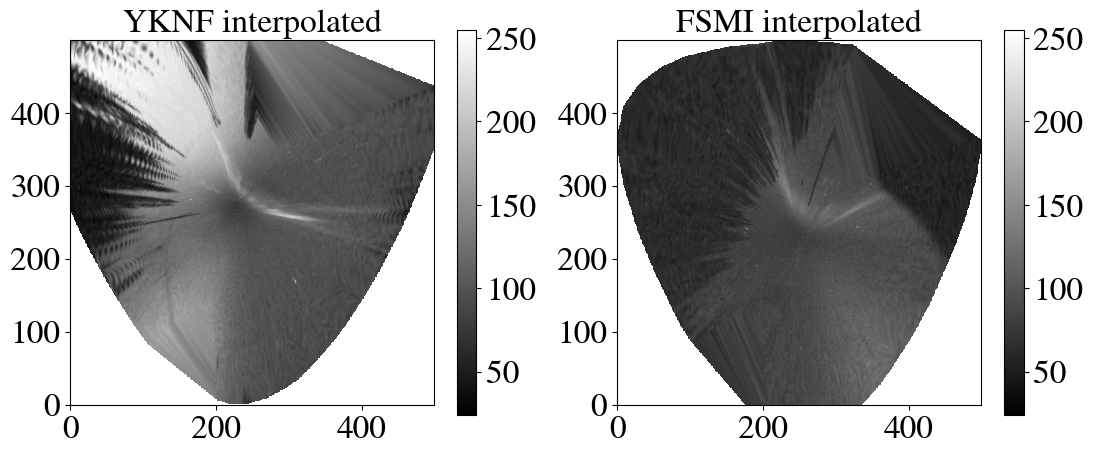


(viewnior:85565): Gtk-CRITICAL **: 15:17:09.803: _gtk_css_image_get_concrete_size: assertion 'default_width > 0' failed

(viewnior:85565): Gtk-CRITICAL **: 15:17:09.803: _gtk_css_image_get_surface: assertion 'surface_width > 0' failed

(viewnior:85565): Gtk-CRITICAL **: 15:17:09.803: _gtk_css_image_get_concrete_size: assertion 'default_width > 0' failed

(viewnior:85565): Gtk-CRITICAL **: 15:17:09.803: _gtk_css_image_get_surface: assertion 'surface_width > 0' failed


In [178]:
vmin = min(np.nanmin(yknf_interp_intensity), np.nanmin(fsmi_interp_intensity))
vmax = max(np.nanmax(yknf_interp_intensity), np.nanmax(fsmi_interp_intensity))

plt.figure(figsize=(20,5))

plt.subplot(1,3,1)
plt.imshow(yknf_interp_intensity, cmap='gray', origin='lower', vmin=vmin, vmax=vmax)
plt.title("YKNF interpolated")
plt.colorbar()

plt.subplot(1,3,2)
plt.imshow(fsmi_interp_intensity, cmap='gray', origin='lower', vmin=vmin, vmax=vmax)
plt.title("FSMI interpolated")
plt.colorbar()


In [162]:
print(lat_min, lat_max, lon_min, lon_max)

47.13051810505199 75.41300866207199 212.98422249531743 283.23093469755713


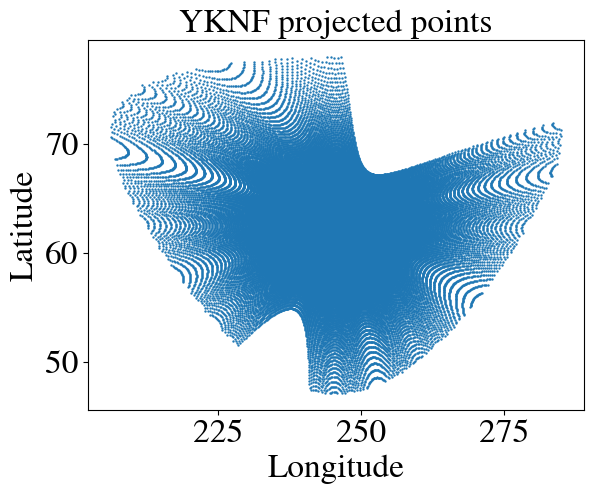

In [163]:
plt.scatter(yknf_points_clean[:,0], yknf_points_clean[:,1], s=0.5)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("YKNF projected points")
plt.show()

In [164]:
print("YKNF lat min/max:", np.nanmin(yknf_lat_110_proj), np.nanmax(yknf_lat_110_proj))
print("YKNF lon min/max:", np.nanmin(yknf_lon_110_proj), np.nanmax(yknf_lon_110_proj))
print("FSMI lat min/max:", np.nanmin(fsmi_lat_110_proj), np.nanmax(fsmi_lat_110_proj))
print("FSMI lon min/max:", np.nanmin(fsmi_lon_110_proj), np.nanmax(fsmi_lon_110_proj))


YKNF lat min/max: 47.13051810505199 77.93189655015098
YKNF lon min/max: 206.27571863156388 284.95405127127765
FSMI lat min/max: 44.6020074892793 75.41300866207199
FSMI lon min/max: 212.98422249531743 283.23093469755713
